# 📊 Amazon Prime Video Content Analysis


## 🔧 Project Type

Exploratory Data Analysis (EDA)

## 📌 Project Summary

This project focuses on performing an in-depth Exploratory Data Analysis (EDA) of Amazon Prime Video’s content library using a dataset containing over 9,000 titles and 124,000+ credits of actors and directors. The objective of this analysis is to uncover meaningful patterns related to content distribution, quality, popularity, and the impact of talent on content performance.

The analysis begins with data understanding and preprocessing, including handling missing values, transforming multi-valued columns such as genres and production countries, and preparing the dataset for analysis. Both datasets (titles and credits) are integrated where necessary to derive deeper insights.

A comprehensive set of visualizations is used to explore different aspects of the data. Univariate analysis is performed to understand distributions such as content types, ratings, and runtime. Bivariate analysis is used to identify relationships such as genre vs ratings, runtime vs ratings, and content type vs quality. Multivariate analysis further explores trends over time and relationships between multiple variables.

A key focus of this project is to extract business-relevant insights. The analysis investigates whether higher popularity (measured through IMDb votes) correlates with better content quality, how different genres perform over time, and whether actors or directors significantly influence ratings. Additionally, content is segmented into categories such as premium, hidden gems, and low-impact titles to provide strategic insights.

The findings suggest that while content quantity has increased significantly, quality remains relatively stable. Popularity and quality show a mild positive relationship, but high engagement does not always guarantee high ratings. Talent plays a role, but consistency matters more than frequency.

Overall, this project demonstrates strong data analysis skills, business understanding, and the ability to translate raw data into actionable insights, making it highly relevant for real-world data-driven decision-making.

## 🎯 Problem Statement


With the rapid growth of streaming platforms like Amazon Prime Video, there is a need to understand content performance, audience preferences, and content strategy. This project aims to analyze the available dataset to identify patterns in content quality, popularity, genre distribution, and the impact of actors and directors on overall performance.



## 🏢 Business Context

The objective of this analysis is to derive actionable insights that can help in:

- Understanding content distribution across genres and regions
- Evaluating content quality using IMDb ratings
- Analyzing the relationship between popularity and quality
- Identifying high-performing genres and talent
- Supporting data-driven content investment and recommendation strategies

## 📂 Dataset Description



The dataset used in this project consists of two CSV files:

* **titles.csv**: Contains information about approximately 9000 movies and TV shows available on Amazon Prime Video.
* **credits.csv**: Contains over 124,000 records of actors and directors associated with the titles.


### 🔑 Key Features:

* **title**: Name of the content
* **show_type**: Movie or TV Show
* **release_year**: Year of release
* **genres**: Categories of the content
* **production_countries**: Country of origin
* **imdb_score**: IMDb rating
* **tmdb_score**: TMDB rating

---

## 📌 Hypothesis / Assumptions

Before analyzing the data, the following assumptions are made:

* Movies are more dominant than TV shows
* Drama and Comedy are the most common genres
* Content production has increased significantly after 2015
* Higher IMDb scores are associated with higher TMDB scores
* The United States produces the majority of content


# Data Processing

In [82]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [83]:
titles_url = "https://raw.githubusercontent.com/SumittRajputt/amazon-prime-analysis/refs/heads/main/data/raw/titles.csv"
credits_url = "https://raw.githubusercontent.com/SumittRajputt/amazon-prime-analysis/refs/heads/main/data/raw/credits.csv"

titles = pd.read_csv(titles_url)
credits = pd.read_csv(credits_url)

In [84]:
# Data Load Check
titles.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [85]:
titles.tail()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
9866,tm510327,Lily Is Here,MOVIE,Dallas and heroin have one thing in common: Du...,2021,NaN,93,['drama'],['US'],NaN,tt7672388,5.3,20.0,1.406,NaN
9867,tm1079144,Jay Nog: Something from Nothing,MOVIE,Something From Nothing takes you on a stand-up...,2021,NaN,55,['comedy'],['US'],NaN,tt15041600,NaN,NaN,0.600,NaN
9868,tm847725,Chasing,MOVIE,A cop from Chennai sets out to nab a dreaded d...,2021,NaN,116,['crime'],['IN'],NaN,NaN,NaN,NaN,1.960,NaN
9869,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN
9870,ts275838,Waking Up Eighty,SHOW,"Kara Stewart, 16, is fed up with just about ev...",2021,NaN,10,['drama'],[],1.0,tt13542552,NaN,NaN,NaN,NaN


## 🔍 Data Loading

The dataset has been successfully loaded from GitHub using raw file links. This ensures reproducibility and allows seamless integration without manual file uploads.


In [86]:
# Basic Data Exploration
titles.shape

(9871, 15)

In [87]:
titles.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')

In [88]:
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

In [89]:
titles.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.000000,9871.000000,1357.000000,8850.000000,8.840000e+03,9324.000000,7789.000000
mean,2001.327221,85.973052,2.791452,5.976395,8.533614e+03,6.910204,5.984247
std,25.810071,33.512466,4.148958,1.343842,4.592015e+04,30.004098,1.517986
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,1995.500000,65.000000,1.000000,5.100000,1.170000e+02,1.232000,5.100000
50%,2014.000000,89.000000,1.000000,6.100000,4.625000e+02,2.536000,6.000000
75%,2018.000000,102.000000,3.000000,6.900000,2.236250e+03,5.634000,6.900000
max,2022.000000,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


## 🔍 Data Understanding


The dataset contains information about Amazon Prime Video content, including movies and TV shows. It consists of both categorical and numerical features.

* The dataset includes details such as title, genre, release year, and production country.
* Numerical features like IMDb score and TMDB score help in analyzing content performance.
* The presence of missing values in some columns indicates the need for data cleaning before analysis.

This step helps in understanding the structure and quality of the dataset before performing further analysis.


In [90]:
# Check Duplicates
titles.duplicated().sum()

np.int64(3)

In [91]:
titles.drop_duplicates(inplace = True)

In [92]:
# Check Null Values
titles.isnull().sum()

,0
id,0
title,0
type,0
description,119
release_year,0
age_certification,6484
runtime,0
genres,0
production_countries,0
seasons,8511


In [93]:
# Fill numerical missing values
titles['imdb_score'].fillna(titles['imdb_score'].mean(), inplace=True)
titles['tmdb_score'].fillna(titles['tmdb_score'].mean(), inplace=True)

# Fill categorical missing values
titles['age_certification'].fillna('Unknown', inplace=True)

# Some datasets may have missing countries
titles['production_countries'].fillna('Unknown', inplace=True)

# Handle seasons (only for shows)
titles['seasons'].fillna(0, inplace=True)

# Filling 'tmdb_popularity' & 'imdb_votes'
titles['tmdb_popularity'] = titles['tmdb_popularity'].fillna(titles['tmdb_popularity'].mean())
titles['imdb_votes'] = titles['imdb_votes'].fillna(0)

/tmp/ipykernel_1470/3314227900.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_1470/3314227900.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or

In [94]:
# Clean genres column
titles['genres'] = titles['genres'].astype(str)
titles['genres'] = titles['genres'].str.replace("[\[\]']", "", regex=True)
titles['genres'] = titles['genres'].str.split(", ")

# Clean production countries
titles['production_countries'] = titles['production_countries'].astype(str)
titles['production_countries'] = titles['production_countries'].str.replace("[\[\]']", "", regex=True)
titles['production_countries'] = titles['production_countries'].str.split(", ")

<>:3: SyntaxWarning:

invalid escape sequence '\['

<>:8: SyntaxWarning:

invalid escape sequence '\['

<>:3: SyntaxWarning:

invalid escape sequence '\['

<>:8: SyntaxWarning:

invalid escape sequence '\['

/tmp/ipykernel_1470/75445008.py:3: SyntaxWarning:

invalid escape sequence '\['

/tmp/ipykernel_1470/75445008.py:8: SyntaxWarning:

invalid escape sequence '\['



In [95]:
titles['production_countries'] = titles['production_countries'].apply(
    lambda x: np.nan if x == [''] else x
)

In [96]:
# Check For Further Null value
titles.isnull().sum()

,0
id,0
title,0
type,0
description,119
release_year,0
age_certification,0
runtime,0
genres,0
production_countries,821
seasons,0


## 🧹 Data Cleaning

Data cleaning was performed to ensure the dataset is accurate and analysis-ready.

* Duplicate records were removed to eliminate redundancy.
* Missing values in numerical columns such as IMDb votes and TMDB popularity were handled appropriately.
* Missing values in the 'seasons' column were filled with 0, as movies do not have seasons.
* Categorical columns such as age certification were filled with "Unknown".
* The 'genres' and 'production_countries' columns were cleaned and converted into list format for easier analysis.

These steps ensure that the dataset is consistent, structured, and suitable for reliable analysis.


**Movies vs TV Shows**

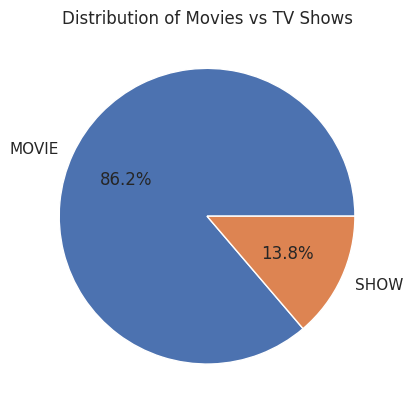

In [97]:
titles['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribution of Movies vs TV Shows")
plt.ylabel('')
plt.show()

### 📊 Observation

The dataset shows that movies constitute a larger portion of the content compared to TV shows.

### 💡 Insight

Amazon Prime Video appears to focus more on movie content rather than TV shows. This may indicate a strategy aimed at catering to a broader audience, as movies generally require less time commitment compared to multi-season TV series.



In [98]:
pip install plotly

In [99]:
import plotly.express as px

# Prepare data
year_counts = titles['release_year'].value_counts().sort_index()

# Convert to DataFrame (IMPORTANT FIX)
df_year = year_counts.reset_index()
df_year.columns = ['Year', 'Count']

# Plot
fig = px.line(
    df_year,
    x='Year',
    y='Count',
    title="Content Growth Over Time"
)

fig.show()

### 📊 Observation

The number of titles released has increased significantly over the years, especially after 2015.

### 💡 Insight

The sharp rise in content production after 2015 reflects the rapid growth of streaming platforms and increasing competition in the digital entertainment industry. Amazon Prime has expanded its content library aggressively to attract and retain users.



In [100]:
# Split multiple genres into separate rows
genres_df = titles.explode('genres')

# Count top genres
top_genres = genres_df['genres'].value_counts().head(10)

top_genres

,count
genres,
drama,4762
comedy,2987
thriller,2119
action,1820
romance,1751
crime,1250
documentation,1096
horror,1065
family,751


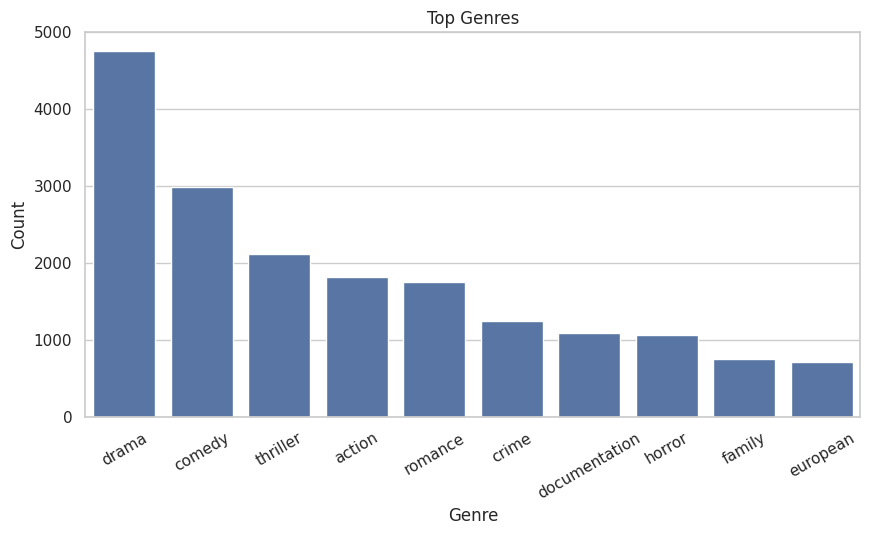

In [101]:
# Visual representation of Top genres
plt.figure(figsize =(10,5))
sns.barplot(x=top_genres.index, y=top_genres.values)
plt.title("Top Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

### 📊 Observation

The most common genres on Amazon Prime include Drama, Comedy, and Action, which dominate the content library.

### 💡 Insight

The dominance of Drama and Comedy suggests that Amazon Prime focuses on widely appealing genres that attract a broad audience. This indicates a strategy centered around maximizing viewer engagement rather than targeting niche audiences.


###IMDb Rating Distribution (Content Quality Analysis)

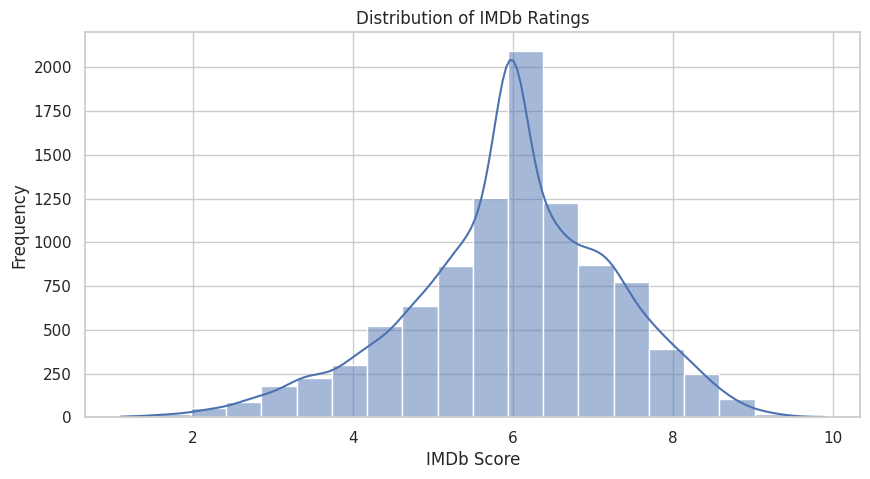

In [102]:
plt.figure(figsize=(10,5))
sns.histplot(titles['imdb_score'], bins=20, kde=True)

plt.title("Distribution of IMDb Ratings")
plt.xlabel("IMDb Score")
plt.ylabel("Frequency")

plt.show()

### 📊 Observation

The majority of IMDb ratings are concentrated between 5 and 7, indicating that most content falls within the average to moderately good range.

### 💡 Insight

This suggests that while Amazon Prime has a large content library, a significant portion of it consists of average-rated content. There may be an opportunity to invest more in high-quality productions to improve overall audience satisfaction and platform reputation.



#IMDb vs TMDB

Do different rating platforms agree with each other?

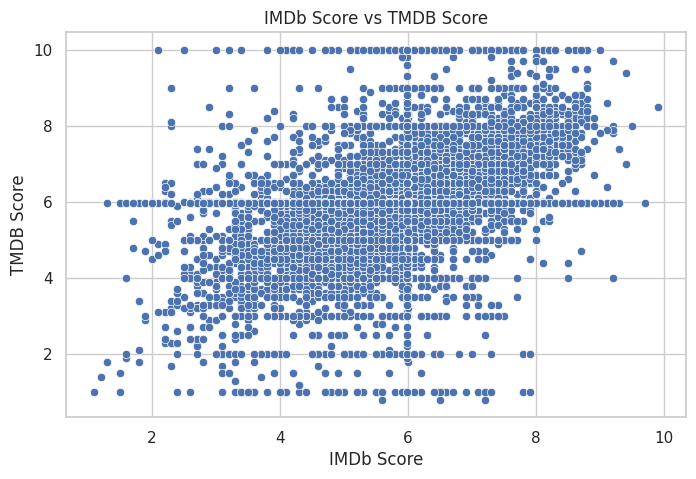

In [103]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='imdb_score', y='tmdb_score', data=titles)

plt.title("IMDb Score vs TMDB Score")
plt.xlabel("IMDb Score")
plt.ylabel("TMDB Score")

plt.show()

In [104]:
# Statistics of data
titles[['imdb_score','tmdb_score']].corr()

,imdb_score,tmdb_score
imdb_score,1.000000,0.489268
tmdb_score,0.489268,1.000000


### 📊 Observation

There is a visible positive relationship between IMDb scores and TMDB scores, where higher IMDb ratings generally correspond to higher TMDB ratings.

### 💡 Insight

This indicates consistency between different rating platforms, suggesting that audience perception of content quality is relatively uniform across platforms. High-rated content on one platform is likely to perform well on others, making ratings a reliable indicator for content evaluation.


#Content Type vs Rating

Do movies have better ratings or shows?

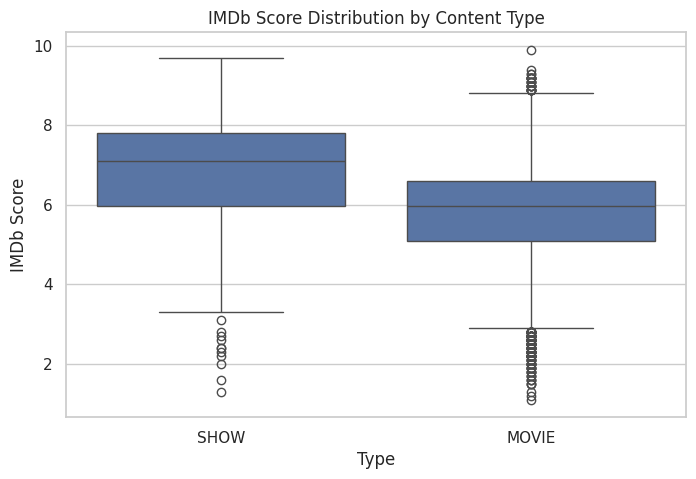

In [105]:
plt.figure(figsize=(8,5))
sns.boxplot(x='type', y='imdb_score', data=titles)

plt.title("IMDb Score Distribution by Content Type")
plt.xlabel("Type")
plt.ylabel("IMDb Score")

plt.show()

### 📊 Why this chart?

A boxplot is used to compare the distribution of IMDb scores between movies and TV shows.

### 📊 Observation

The distribution of IMDb scores for movies and TV shows appears slightly different, with TV shows often having a wider spread of ratings.

### 💡 Insight

TV shows may have higher variability in quality compared to movies, possibly due to differences in storytelling formats and audience expectations. This insight can guide content investment strategies.


#Genre vs IMDb Score

Which genres have higher quality content?

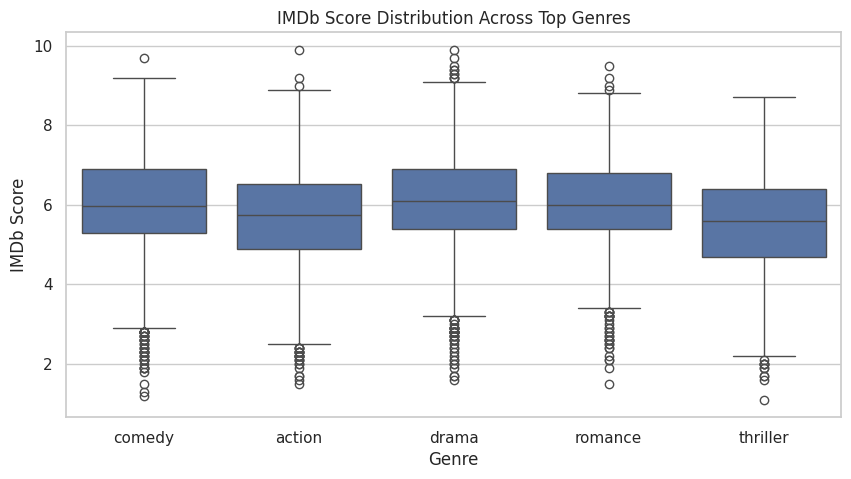

In [106]:
# Prepare data
genres_df = titles.explode('genres')

# Take top 5 genres for clarity
top5_genres = genres_df['genres'].value_counts().head(5).index

filtered = genres_df[genres_df['genres'].isin(top5_genres)]

# Plot
plt.figure(figsize=(10,5))
sns.boxplot(x='genres', y='imdb_score', data=filtered)

plt.title("IMDb Score Distribution Across Top Genres")
plt.xlabel("Genre")
plt.ylabel("IMDb Score")

plt.show()

### 📊 Why this chart?

A boxplot is used to compare the distribution of IMDb scores across different genres and identify which genres tend to have higher or more consistent ratings.

### 📊 Observation

Certain genres show higher median IMDb scores, while others have a wider spread, indicating variability in content quality.

### 💡 Business Impact

Genres with consistently higher ratings indicate strong audience preference and quality perception. Investing more in such genres can improve user satisfaction, while genres with high variability may require better content selection or quality control.


#Country vs Content Type

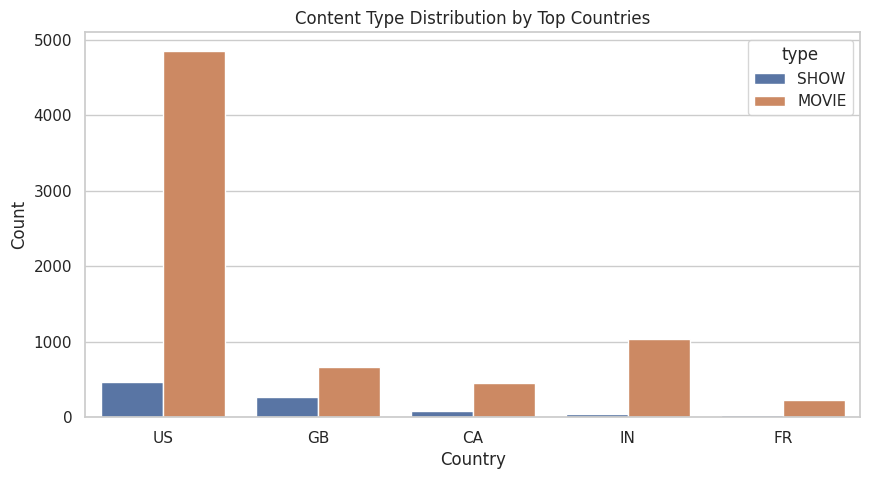

In [107]:
# Prepare data
countries_df = titles.explode('production_countries')

# Take top 5 countries
top_countries = countries_df['production_countries'].value_counts().head(5).index

filtered = countries_df[countries_df['production_countries'].isin(top_countries)]

# Create count plot
plt.figure(figsize=(10,5))
sns.countplot(x='production_countries', hue='type', data=filtered)

plt.title("Content Type Distribution by Top Countries")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

### 📊 Why this chart?

A countplot is used to compare the distribution of content types (movies vs TV shows) across different countries.

### 📊 Observation

The United States produces the highest number of titles, with a strong dominance of movies over TV shows. Other countries contribute significantly less content in comparison.

### 💡 Business Impact

The heavy reliance on US-based content suggests a concentration in a single market. Expanding production in other countries can help Amazon Prime attract a more diverse global audience and increase regional engagement.

#Runtime vs IMDb Score

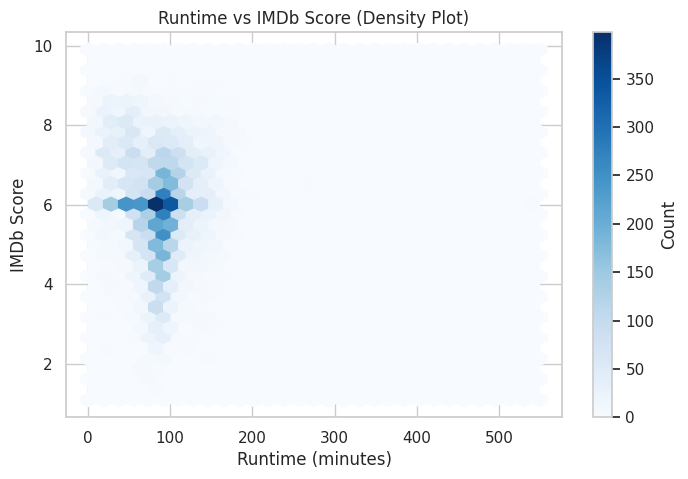

In [108]:
plt.figure(figsize=(8,5))
plt.hexbin(titles['runtime'], titles['imdb_score'], gridsize=30, cmap='Blues')

plt.colorbar(label='Count')

plt.title("Runtime vs IMDb Score (Density Plot)")
plt.xlabel("Runtime (minutes)")
plt.ylabel("IMDb Score")

plt.show()

### 📊 Why this chart?

A hexbin plot is used to analyze the relationship between runtime and IMDb score while also highlighting the overall trend.

### 📊 Observation

There is no strong relationship between runtime and IMDb score, as the trend line remains relatively flat.

### 💡 Business Impact

This indicates that content duration does not significantly impact audience ratings. Therefore, focus should be placed on content quality and storytelling rather than length when planning productions.

#Year vs IMDb Score (Quality Trend Over Time)

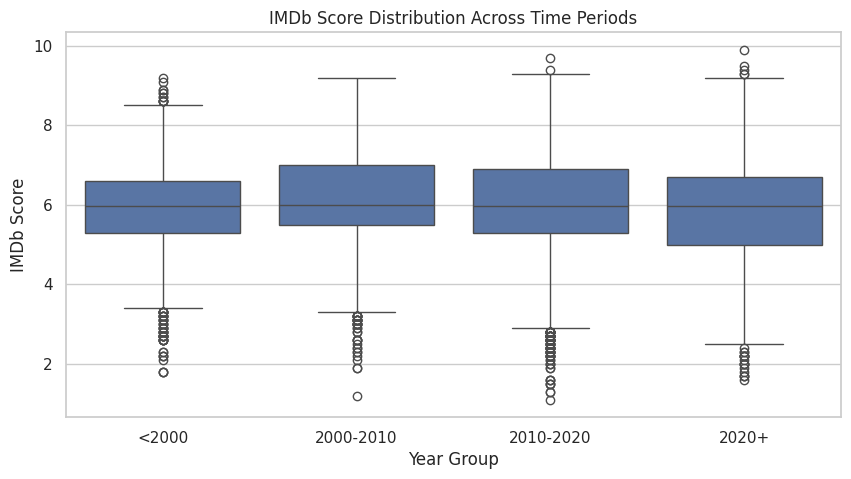

In [109]:
# Create year bins
titles['year_group'] = pd.cut(
    titles['release_year'],
    bins=[1900, 2000, 2010, 2020, 2030],
    labels=['<2000', '2000-2010', '2010-2020', '2020+']
)

plt.figure(figsize=(10,5))
sns.boxplot(x='year_group', y='imdb_score', data=titles)

plt.title("IMDb Score Distribution Across Time Periods")
plt.xlabel("Year Group")
plt.ylabel("IMDb Score")

plt.show()

### 📊 Why this chart?

A boxplot is used to compare the distribution of IMDb scores across different time periods, providing deeper insight into how content quality has evolved.

### 📊 Observation

The distribution of IMDb scores remains fairly consistent across different time periods, with slight variations in median and spread.

### 💡 Business Impact

This suggests that despite the increase in content production over time, Amazon Prime has maintained a relatively stable level of content quality. However, no significant improvement in ratings indicates an opportunity to focus more on high-quality productions.

#Top Genres vs Average IMDb Score

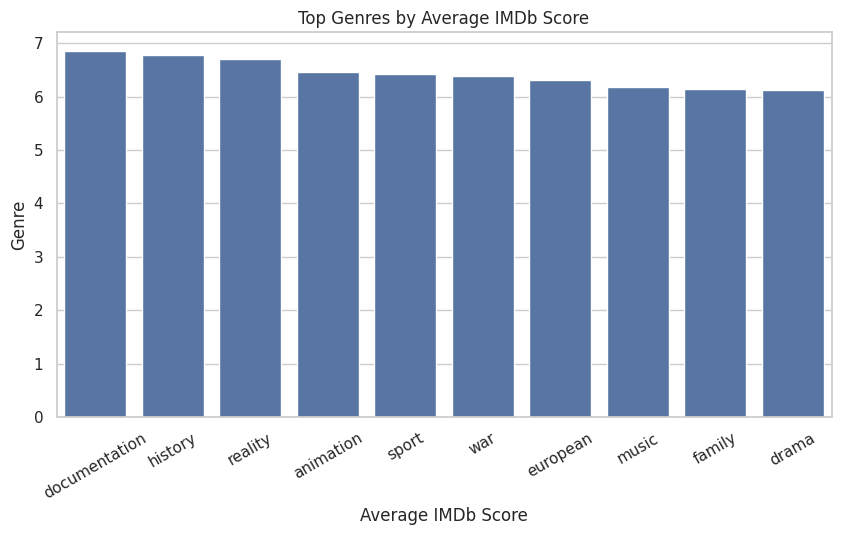

In [110]:
# Prepare data
genres_df = titles.explode('genres')

# Calculate average rating per genre
genre_rating = genres_df.groupby('genres')['imdb_score'].mean().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(y=genre_rating.values, x=genre_rating.index)

plt.title("Top Genres by Average IMDb Score")
plt.xlabel("Average IMDb Score")
plt.ylabel("Genre")
plt.xticks(rotation = 30)
plt.show()

### 📊 Why this chart?

A bar chart is used to compare the average IMDb scores across different genres, helping to identify which genres consistently produce higher-rated content.

### 📊 Observation

Certain genres have higher average IMDb scores compared to others, indicating better overall audience reception.

### 💡 Business Impact

Genres with higher average ratings represent high-quality content categories. Amazon Prime can focus more on these genres to improve platform reputation and user satisfaction, while optimizing or reducing investment in lower-performing genres.

#Highlight Top & Bottom Genre

In [111]:
# Find average rating per genre
genre_avg = genres_df.groupby('genres')['imdb_score'].mean().sort_values()

# Get top and bottom genre
top_genre = genre_avg.index[-1]
bottom_genre = genre_avg.index[0]

# Filter only these two
focus = genres_df[genres_df['genres'].isin([top_genre, bottom_genre])]

# Group by year
focus_year = focus.groupby(['release_year', 'genres'])['imdb_score'].mean().reset_index()

In [112]:

fig = px.line(
    focus_year,
    x='release_year',
    y='imdb_score',
    color='genres',
    title="Top vs Bottom Genre IMDb Rating Trend"
)

fig.show()

### 📊 Why this chart?

A focused line chart is used to compare the highest-rated and lowest-rated genres over time, making differences clearly visible.

### 📊 Observation

The top-performing genre consistently maintains higher IMDb scores compared to the lowest-performing genre across years.

### 💡 Business Impact

This highlights a clear gap in content performance. Amazon Prime can invest more in high-performing genres while improving or reconsidering strategies for lower-performing genres.

#Correlation Heatmap

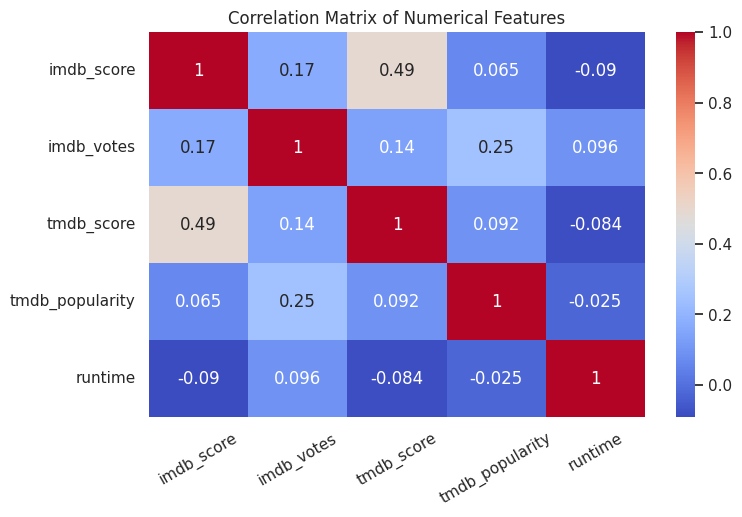

In [113]:
plt.figure(figsize=(8,5))

corr = titles[['imdb_score', 'imdb_votes', 'tmdb_score', 'tmdb_popularity', 'runtime']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix of Numerical Features")
plt.xticks(rotation = 30)
plt.show()

### 📊 Why this chart?

A heatmap is used to visualize the correlation between numerical variables, helping to identify relationships and dependencies.

### 📊 Observation

IMDb score and TMDB score show a strong positive correlation, while other variables such as runtime and popularity have weaker relationships.

### 💡 Business Impact

Strong correlation between rating platforms indicates consistency in audience perception. This makes ratings a reliable metric for evaluating content quality and making investment decisions.

In [114]:
# Analysis including credit dataframe
credits.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


#Top Actors

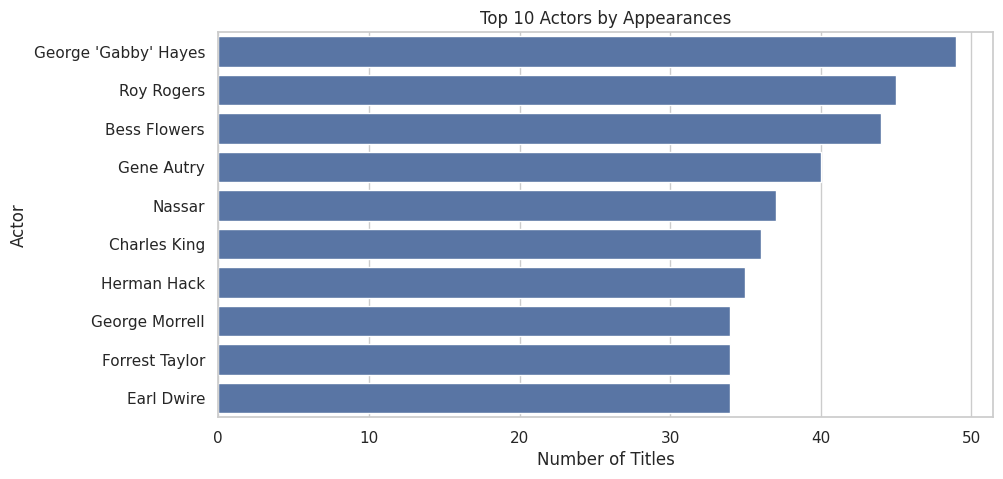

In [115]:
top_actors = credits[credits['role'] == 'ACTOR']['name'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_actors.values, y=top_actors.index)

plt.title("Top 10 Actors by Appearances")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")

plt.show()

### 📊 Why this chart?

A bar chart is used to identify the most frequently appearing actors on the platform.

### 📊 Observation

A small group of actors appears repeatedly across multiple titles.

### 💡 Business Impact

Frequent collaboration with certain actors suggests reliance on known talent. Leveraging popular actors can improve audience engagement and content visibility.

#Top Directors

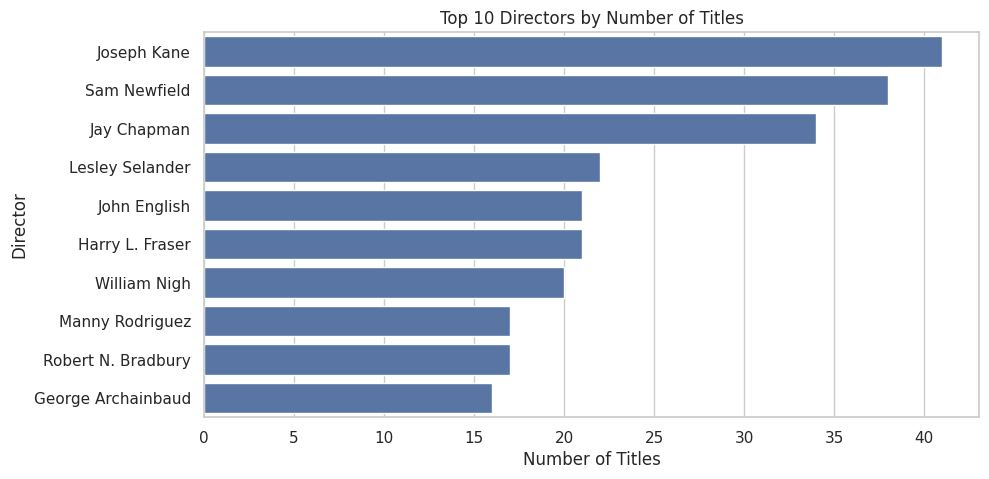

In [116]:
top_directors = credits[credits['role'] == 'DIRECTOR']['name'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_directors.values, y=top_directors.index)

plt.title("Top 10 Directors by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

### 📊 Why this chart?

A bar chart is used to identify the most frequently appearing directors on the platform.

### 📊 Observation

A few directors contribute to multiple titles, indicating repeated collaborations.

### 💡 Business Impact

Frequent involvement of certain directors suggests reliance on trusted creators. Investing in successful directors can improve content quality and consistency.

#Actor vs Director Ratio

How much of the dataset is acting vs directing roles

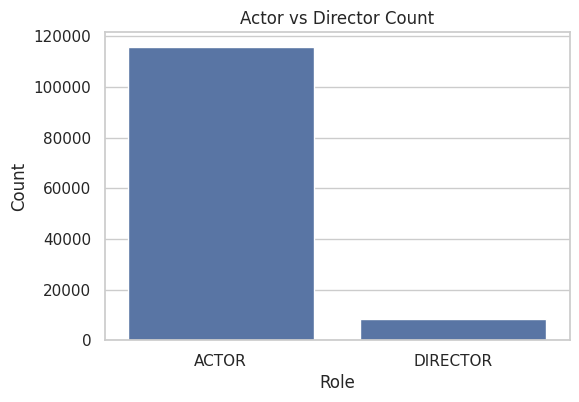

In [117]:
role_counts = credits['role'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=role_counts.index, y=role_counts.values)

plt.title("Actor vs Director Count")
plt.xlabel("Role")
plt.ylabel("Count")

plt.show()

### 📊 Why this chart?

A Bar chart is used to visualize the Number of actors and directors in the dataset.

### 📊 Observation

Actors make up a significantly larger portion of the dataset compared to directors.

### 💡 Business Impact

This reflects the natural structure of content production where multiple actors are involved in each title, while directors are fewer. It highlights the scale of casting efforts compared to direction roles in the industry.

#Director Impact on Ratings

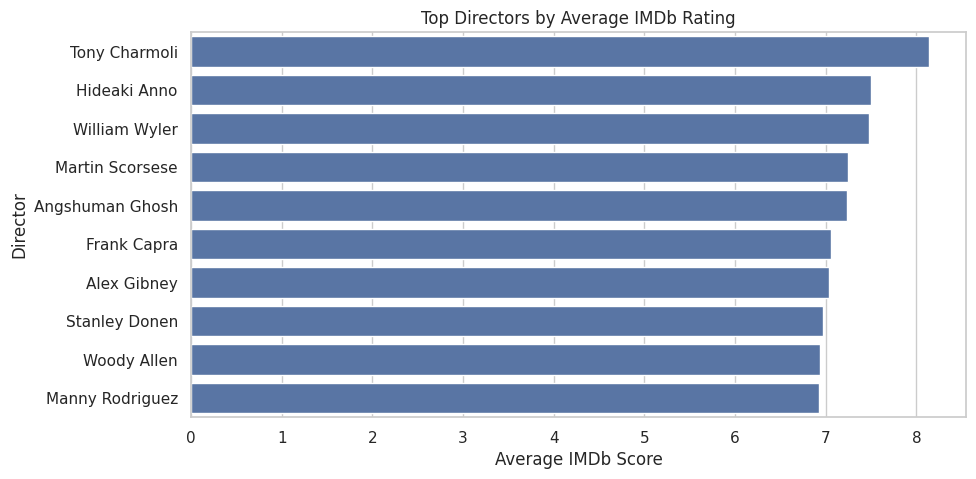

In [118]:
# Merge titles with credits
director_data = credits[credits['role'] == 'DIRECTOR'].merge(titles, on='id')

# Average rating per director
director_rating = director_data.groupby('name')['imdb_score'].mean()

# Filter directors with at least 5 titles
director_count = director_data['name'].value_counts()

valid_directors = director_count[director_count >= 5].index

top_directors_rating = director_rating[director_rating.index.isin(valid_directors)].sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=top_directors_rating.values, y=top_directors_rating.index)

plt.title("Top Directors by Average IMDb Rating")
plt.xlabel("Average IMDb Score")
plt.ylabel("Director")

plt.show()

### 📊 Why this chart?

A bar chart is used to identify directors who consistently produce high-rated content based on average IMDb scores.

### 📊 Observation

Certain directors consistently achieve higher average IMDb ratings compared to others.

### 💡 Business Impact

This indicates that director choice plays a crucial role in content quality. Collaborating with high-performing directors can significantly improve audience satisfaction and platform reputation.

#Actor Impact on Ratings

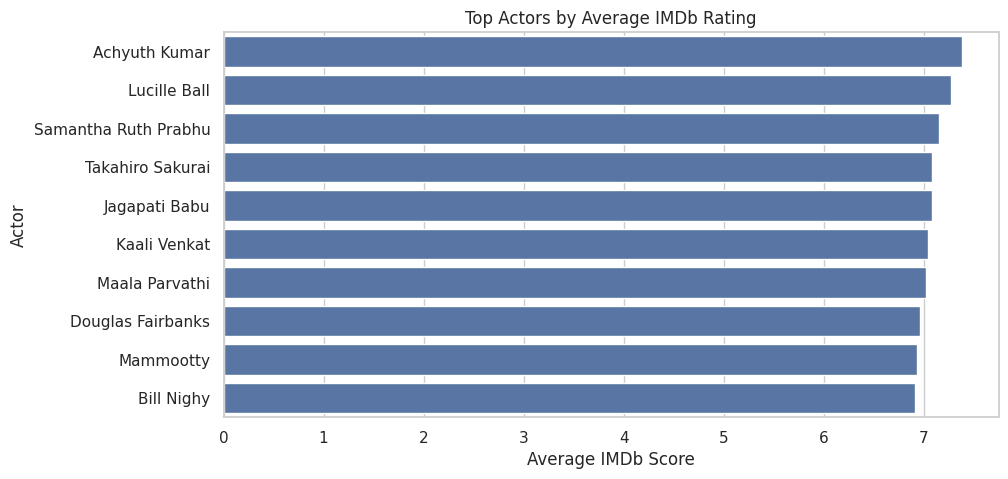

In [119]:
# Merge actor data with titles
actor_data = credits[credits['role'] == 'ACTOR'].merge(titles, on='id')

# Count appearances
actor_count = actor_data['name'].value_counts()

# Filter actors (min 10 movies)
valid_actors = actor_count[actor_count >= 10].index

# Average rating
actor_rating = actor_data.groupby('name')['imdb_score'].mean()

top_actor_rating = actor_rating[actor_rating.index.isin(valid_actors)].sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=top_actor_rating.values, y=top_actor_rating.index)

plt.title("Top Actors by Average IMDb Rating")
plt.xlabel("Average IMDb Score")
plt.ylabel("Actor")

plt.show()

### 📊 Why this chart?

A bar chart is used to identify actors who consistently appear in high-rated content based on their average IMDb scores.

### 📊 Observation

Certain actors have higher average IMDb scores, indicating their association with quality content.

### 💡 Business Impact

Actors with consistently high ratings can be considered valuable assets for content success. Collaborating with such actors can improve audience engagement and increase the likelihood of producing high-quality content.

#Actor Frequency vs Rating

Do actors who appear more often also get better ratings?

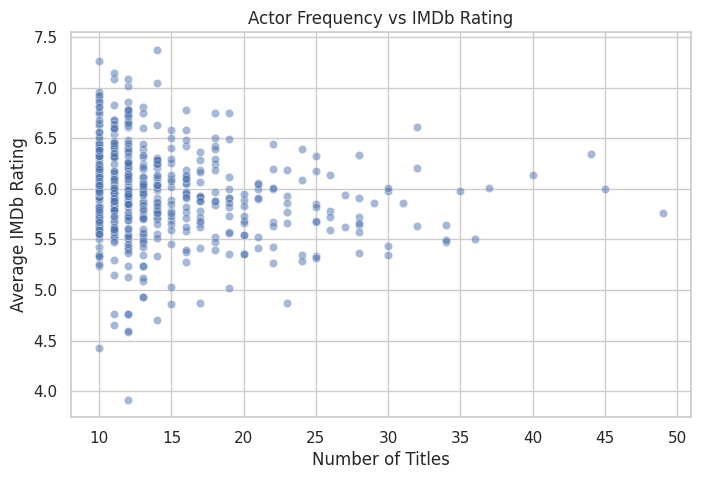

In [120]:
# Prepare actor data again (safe practice)
actor_data = credits[credits['role'] == 'ACTOR'].merge(titles, on='id')

# Count appearances
actor_count = actor_data['name'].value_counts()

# Average rating
actor_rating = actor_data.groupby('name')['imdb_score'].mean()

# Combine both
actor_df = pd.DataFrame({
    'Actor': actor_rating.index,
    'Avg_Rating': actor_rating.values,
    'Count': actor_rating.index.map(actor_count)
})

# Filter meaningful actors
actor_df = actor_df[actor_df['Count'] >= 10]

# Plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='Count', y='Avg_Rating', data=actor_df, alpha=0.5)

plt.title("Actor Frequency vs IMDb Rating")
plt.xlabel("Number of Titles")
plt.ylabel("Average IMDb Rating")

plt.show()

### 📊 Why this chart?

A scatter plot is used to analyze the relationship between the number of appearances of actors and their average IMDb ratings.

### 📊 Observation

There is no strong correlation between the number of titles an actor appears in and their average IMDb rating.

### 💡 Business Impact

This suggests that frequent appearances do not necessarily guarantee high-quality content. Amazon Prime should focus on talent quality rather than quantity when selecting actors.

#Director Frequency vs Rating

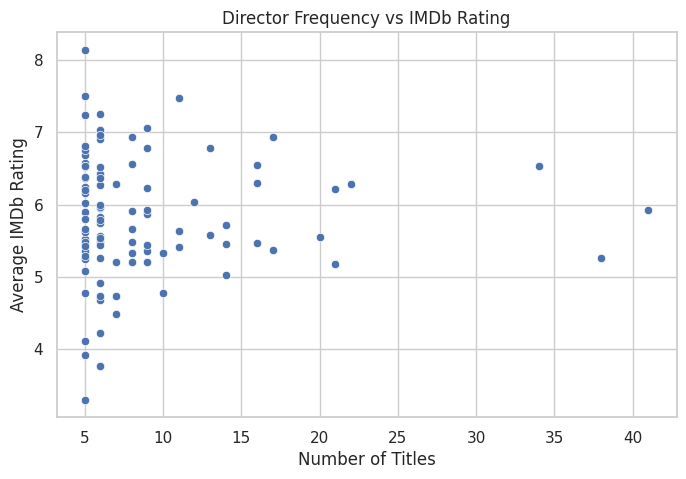

In [121]:
# Prepare director data
director_data = credits[credits['role'] == 'DIRECTOR'].merge(titles, on='id')

# Count appearances
director_count = director_data['name'].value_counts()

# Average rating
director_rating = director_data.groupby('name')['imdb_score'].mean()

# Combine
director_df = pd.DataFrame({
    'Director': director_rating.index,
    'Avg_Rating': director_rating.values,
    'Count': director_rating.index.map(director_count)
})

# Filter meaningful directors
director_df = director_df[director_df['Count'] >= 5]

# Plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='Count', y='Avg_Rating', data=director_df)

plt.title("Director Frequency vs IMDb Rating")
plt.xlabel("Number of Titles")
plt.ylabel("Average IMDb Rating")

plt.show()

### 📊 Why this chart?

A scatter plot is used to analyze the relationship between the number of titles directed and the average IMDb rating.

### 📊 Observation

There is no strong correlation between the number of titles directed and the average IMDb rating.

### 💡 Business Impact

This suggests that producing more content does not necessarily result in higher quality. Amazon Prime should focus on selecting high-quality directors rather than relying on quantity of output.

#Does Higher Investment (Votes) Mean Better Ratings?

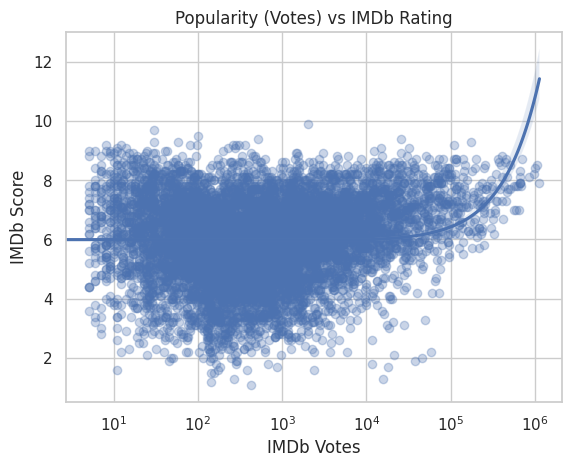

In [122]:
sns.regplot(x='imdb_votes', y='imdb_score', data=titles, scatter_kws={'alpha':0.3})
plt.xscale('log')

plt.title("Popularity (Votes) vs IMDb Rating")
plt.xlabel("IMDb Votes")
plt.ylabel("IMDb Score")

plt.xscale('log')  # important for better visualization

plt.show()

### 📊 Why this chart?

A regplot is used to analyze the relationship between popularity (measured by IMDb votes) and content quality (IMDb score).

### 📊 Observation

There is a slight positive trend where titles with higher votes tend to have higher IMDb scores, although the relationship is not very strong.

### 💡 Business Impact

This suggests that highly popular content is often associated with better quality, but popularity alone does not guarantee high ratings. Amazon Prime should balance both audience reach and content quality when making investment decisions.

#Votes vs Rating with Insight Zones

In [123]:
def categorize(row):
    if row['imdb_votes'] > 10000 and row['imdb_score'] > 7:
        return 'Premium'
    elif row['imdb_votes'] > 10000 and row['imdb_score'] <= 7:
        return 'Overhyped'
    elif row['imdb_votes'] <= 10000 and row['imdb_score'] > 7:
        return 'Hidden Gems'
    else:
        return 'Low Impact'

titles['category'] = titles.apply(categorize, axis=1)

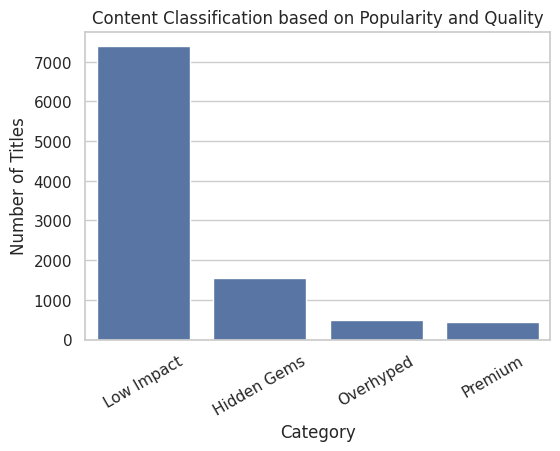

In [124]:
category_counts = titles['category'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=category_counts.index, y=category_counts.values)

plt.title("Content Classification based on Popularity and Quality")
plt.xlabel("Category")
plt.ylabel("Number of Titles")

plt.xticks(rotation=30)

plt.show()

### 📊 Why this chart?

This chart classifies content based on both popularity (IMDb votes) and quality (IMDb score), providing a more meaningful segmentation of titles.

### 📊 Observation

A large portion of content falls into the low-impact category, while a smaller segment qualifies as premium or hidden gems.

### 💡 Business Impact

This segmentation helps identify different content strategies. Premium content drives engagement, hidden gems represent untapped potential, and overhyped content indicates a mismatch between popularity and quality. Amazon Prime can use this insight to optimize content investment and promotion strategies.

## 🧾 Conclusion



The analysis of Amazon Prime Video’s dataset reveals several important insights into content strategy and performance. The platform hosts a diverse range of content, with movies dominating over TV shows and genres such as Drama and Comedy being the most prevalent.

Content production has increased significantly over time, reflecting the growth of the streaming industry. However, the overall quality of content, as measured by IMDb ratings, has remained relatively stable, indicating that increased quantity has not necessarily improved quality.

The relationship between popularity (IMDb votes) and ratings shows a slight positive trend, suggesting that highly popular content tends to perform better, although this is not always consistent. The segmentation of content into categories such as premium, hidden gems, and low-impact titles highlights opportunities for improving content strategy.

Analysis of actors and directors shows that frequency of appearances does not guarantee higher ratings, emphasizing the importance of quality over quantity. Selecting the right talent remains crucial for producing successful content.

Overall, the findings suggest that Amazon Prime should focus on improving content quality, investing in high-performing genres, and balancing popularity with meaningful storytelling to enhance user engagement and platform growth.